# RetailPulse | Online Retail II EDA

Professional exploratory data analysis notebook for the UCI Online Retail II dataset. The goal is to uncover transaction quality issues, cancellation behavior, sales patterns, country-level performance, product performance, and customer purchasing behavior to support an industry-grade retail analytics workflow.

## Analysis Workflow

1. Load both workbook sheets efficiently.
2. Standardize column names and data types.
3. Review dataset size, schema, missingness, and duplicates.
4. Analyze cancellations and their business impact.
5. Study revenue trends, geography, products, and customers.
6. Close with a correlation heatmap and business takeaways.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

DATA_FILE = Path(r'c:/Users/jay19/Desktop/Zidio Project/online_retail_II.xlsx')
USE_COLUMNS = ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

print(f'Using dataset: {DATA_FILE}')

Using dataset: c:\Users\jay19\Desktop\Zidio Project\online_retail_II.xlsx


In [2]:
def load_retail_data(file_path: Path) -> pd.DataFrame:
    """Load the dataset efficiently with format-aware fallbacks."""
    if file_path.suffix.lower() in {'.xlsx', '.xls'}:
        workbook = pd.ExcelFile(file_path, engine='openpyxl')
        frames = []
        for sheet_name in workbook.sheet_names:
            frame = pd.read_excel(
                workbook,
                sheet_name=sheet_name,
                usecols=USE_COLUMNS,
                dtype={
                    'Invoice': 'string',
                    'StockCode': 'string',
                    'Description': 'string',
                    'Customer ID': 'string',
                    'Country': 'string',
                },
                parse_dates=['InvoiceDate'],
                engine='openpyxl',
            )
            frame['SourceSheet'] = sheet_name
            frames.append(frame)
        return pd.concat(frames, ignore_index=True)

    encodings = ['utf-8-sig', 'utf-8', 'latin1', 'cp1252']
    last_error = None
    for encoding in encodings:
        try:
            return pd.read_csv(file_path, encoding=encoding, usecols=USE_COLUMNS)
        except Exception as error:
            last_error = error
    raise last_error

raw_df = load_retail_data(DATA_FILE)
raw_df.columns = [column.strip().replace(' ', '') for column in raw_df.columns]
raw_df = raw_df.rename(columns={'Invoice': 'InvoiceNo', 'Price': 'UnitPrice', 'CustomerID': 'CustomerID'})
raw_df['InvoiceNo'] = raw_df['InvoiceNo'].astype('string').str.strip()
raw_df['StockCode'] = raw_df['StockCode'].astype('string').str.strip()
raw_df['Description'] = raw_df['Description'].astype('string').str.strip()
raw_df['Country'] = raw_df['Country'].astype('string').str.strip()
raw_df['InvoiceDate'] = pd.to_datetime(raw_df['InvoiceDate'], errors='coerce')
raw_df['Quantity'] = pd.to_numeric(raw_df['Quantity'], errors='coerce')
raw_df['UnitPrice'] = pd.to_numeric(raw_df['UnitPrice'], errors='coerce')
raw_df['CustomerID'] = pd.to_numeric(raw_df['CustomerID'], errors='coerce').astype('Int64')
raw_df['TransactionValue'] = raw_df['Quantity'] * raw_df['UnitPrice']
raw_df['IsCancellation'] = raw_df['InvoiceNo'].str.startswith('C', na=False)
raw_df['InvoiceMonth'] = raw_df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

sales_df = raw_df.loc[~raw_df['IsCancellation']].copy()
sales_df = sales_df.loc[sales_df['Quantity'].gt(0) & sales_df['UnitPrice'].gt(0)].copy()
sales_df['TransactionValue'] = sales_df['Quantity'] * sales_df['UnitPrice']
sales_df['InvoiceMonth'] = sales_df['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

raw_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SourceSheet,TransactionValue,IsCancellation,InvoiceMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010,83.40,False,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,81.00,False,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,81.00,False,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010,100.80,False,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,30.00,False,2009-12-01


In [3]:
print(f'Combined dataset shape: {raw_df.shape}')
print(f'Analysis-ready sales dataset shape: {sales_df.shape}')
print('Workbook sheets included:', raw_df['SourceSheet'].nunique())
print('Date range:', raw_df['InvoiceDate'].min(), 'to', raw_df['InvoiceDate'].max())

raw_df.info()

raw_df.describe(include='all').T[['count', 'unique', 'top', 'freq', 'mean', 'min', 'max']]

Combined dataset shape: (1067371, 12)
Analysis-ready sales dataset shape: (1041670, 12)
Workbook sheets included: 2
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 12 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   InvoiceNo         1067371 non-null  string        
 1   StockCode         1067371 non-null  string        
 2   Description       1062989 non-null  string        
 3   Quantity          1067371 non-null  int64         
 4   InvoiceDate       1067371 non-null  datetime64[ns]
 5   UnitPrice         1067371 non-null  float64       
 6   CustomerID        824364 non-null   Int64         
 7   Country           1067371 non-null  string        
 8   SourceSheet       1067371 non-null  object        
 9   TransactionValue  1067371 non-null  float64       
 10  IsCancellation    1067371 non-null  boo

,count,unique,top,freq,mean,min,max
InvoiceNo,1067371,53628,537434,1350,NaN,NaN,NaN
StockCode,1067371,5304,85123A,5829,NaN,NaN,NaN
Description,1062989,5655,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN
Quantity,"1,067,371.00",NaN,NaN,NaN,9.94,"-80,995.00","80,995.00"
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2011-12-09 12:50:00
UnitPrice,"1,067,371.00",NaN,NaN,NaN,4.65,"-53,594.36","38,970.00"
CustomerID,"824,364.00",<NA>,<NA>,<NA>,"15,324.64","12,346.00","18,287.00"
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN
SourceSheet,1067371,2,Year 2010-2011,541910,NaN,NaN,NaN
TransactionValue,"1,067,371.00",NaN,NaN,NaN,18.07,"-168,469.60","168,469.60"


In [4]:
missing_counts = raw_df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(raw_df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing_counts, 'Missing %': missing_pct})
missing_summary = missing_summary.loc[missing_summary['Missing Count'] > 0]

display(missing_summary)

if not missing_summary.empty:
    fig = px.bar(
        missing_summary.reset_index(),
        x='index',
        y='Missing Count',
        text='Missing %',
        title='Missing Value Analysis',
        labels={'index': 'Column', 'Missing Count': 'Missing Records'}
    )
    fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
    fig.update_layout(xaxis_tickangle=-35, height=500)
    fig.show()
else:
    print('No missing values detected in the loaded dataset.')

,Missing Count,Missing %
CustomerID,243007,22.77
Description,4382,0.41


**Business insight:** Missing customer identifiers and product descriptions are the most important quality gaps to monitor because they reduce attribution accuracy in customer and product analytics. The sales pipeline should therefore keep a clean-rule layer that excludes or flags incomplete rows before executive reporting.

In [5]:
duplicate_rows = int(raw_df.duplicated().sum())
unique_rows = int(len(raw_df) - duplicate_rows)
duplicate_summary = pd.DataFrame({
    'Row Type': ['Unique Rows', 'Duplicate Rows'],
    'Record Count': [unique_rows, duplicate_rows]
})
display(duplicate_summary)

fig = px.bar(
    duplicate_summary,
    x='Row Type',
    y='Record Count',
    color='Row Type',
    title='Duplicate Row Analysis',
    text='Record Count'
)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, height=450)
fig.show()

if duplicate_rows > 0:
    display(raw_df[raw_df.duplicated(keep=False)].head(10))

,Row Type,Record Count
0,Unique Rows,1055238
1,Duplicate Rows,12133


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SourceSheet,TransactionValue,IsCancellation,InvoiceMonth
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,Year 2009-2010,3.75,False,2009-12-01
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,Year 2009-2010,3.75,False,2009-12-01
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,Year 2009-2010,3.75,False,2009-12-01
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329,United Kingdom,Year 2009-2010,7.80,False,2009-12-01
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329,United Kingdom,Year 2009-2010,5.10,False,2009-12-01
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,Year 2009-2010,3.75,False,2009-12-01
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329,United Kingdom,Year 2009-2010,1.95,False,2009-12-01
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329,United Kingdom,Year 2009-2010,5.10,False,2009-12-01
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329,United Kingdom,Year 2009-2010,7.80,False,2009-12-01
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329,United Kingdom,Year 2009-2010,3.75,False,2009-12-01


**Business insight:** Duplicate rows can inflate revenue and product demand if they are not handled before aggregation. Even when duplicates are relatively small, they should be reviewed at the transaction level because they can distort top-product and customer-frequency KPIs.

In [6]:
cancellation_summary = raw_df.groupby('IsCancellation').agg(
    Invoices=('InvoiceNo', 'nunique'),
    Rows=('InvoiceNo', 'size'),
    NetRevenue=('TransactionValue', 'sum')
).reset_index()
cancellation_summary['IsCancellation'] = cancellation_summary['IsCancellation'].map({False: 'Completed', True: 'Cancellation'})
display(cancellation_summary)

fig = make_subplots(rows=1, cols=2, subplot_titles=('Invoice Volume', 'Net Revenue Impact'))
fig.add_trace(go.Bar(x=cancellation_summary['IsCancellation'], y=cancellation_summary['Invoices'], name='Invoices'), row=1, col=1)
fig.add_trace(go.Bar(x=cancellation_summary['IsCancellation'], y=cancellation_summary['NetRevenue'], name='Net Revenue'), row=1, col=2)
fig.update_layout(title='Cancellation Invoice Analysis', height=500, showlegend=False)
fig.show()

,IsCancellation,Invoices,Rows,NetRevenue
0,Completed,45336,1047877,"20,813,918.43"
1,Cancellation,8292,19494,"-1,526,667.86"


**Business insight:** Cancellations are not just operational noise; they directly affect net revenue and may reveal stock issues, fulfilment problems, or customer dissatisfaction. A retail analytics platform should track cancellation share over time and investigate spikes by product, country, or customer segment.

In [7]:
monthly_sales = (
    sales_df.groupby('InvoiceMonth', as_index=False)['TransactionValue']
    .sum()
    .sort_values('InvoiceMonth')
)
monthly_sales['MonthLabel'] = monthly_sales['InvoiceMonth'].dt.strftime('%Y-%m')

fig = px.line(
    monthly_sales,
    x='InvoiceMonth',
    y='TransactionValue',
    markers=True,
    title='Sales Trend Analysis',
    labels={'InvoiceMonth': 'Month', 'TransactionValue': 'Revenue'}
)
fig.update_traces(line=dict(width=3, color='#2A6F97'))
fig.update_layout(height=500)
fig.show()

monthly_sales.tail(12)

,InvoiceMonth,TransactionValue,MonthLabel
13,2011-01-01,"691,364.56",2011-01
14,2011-02-01,"523,631.89",2011-02
15,2011-03-01,"717,639.36",2011-03
16,2011-04-01,"537,808.62",2011-04
17,2011-05-01,"770,536.02",2011-05
18,2011-06-01,"761,739.90",2011-06
19,2011-07-01,"719,221.19",2011-07
20,2011-08-01,"759,138.38",2011-08
21,2011-09-01,"1,058,590.17",2011-09
22,2011-10-01,"1,154,979.30",2011-10


**Business insight:** Monthly sales trends are the core demand signal for planning inventory, campaigns, and staffing. The platform should watch for seasonal peaks, troughs, and growth inflections, then connect those movements to promotions, holidays, and product launches.

In [8]:
country_sales = (
    sales_df.groupby('Country', as_index=False)['TransactionValue']
    .sum()
    .sort_values('TransactionValue', ascending=False)
    .head(10)
)
country_sales['Country'] = country_sales['Country'].astype(str)

fig = px.bar(
    country_sales.sort_values('TransactionValue'),
    x='TransactionValue',
    y='Country',
    orientation='h',
    title='Country-wise Sales',
    text='TransactionValue',
    labels={'TransactionValue': 'Revenue'}
)
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(height=600)
fig.show()

country_sales.sort_values('TransactionValue', ascending=False)

,Country,TransactionValue
40,United Kingdom,"17,870,977.78"
11,EIRE,"664,431.78"
26,Netherlands,"554,232.34"
15,Germany,"431,262.46"
14,France,"356,944.60"
0,Australia,"169,968.11"
34,Spain,"109,178.53"
36,Switzerland,"101,011.29"
35,Sweden,"91,903.72"
10,Denmark,"69,862.19"


**Business insight:** Country concentration is critical for go-to-market planning. If a single market dominates revenue, the business is exposed to shipping cost, regulation, or demand shocks; if international markets are growing quickly, they deserve targeted localization and logistics support.

In [9]:
top_products = (
    sales_df.groupby('Description', as_index=False)['TransactionValue']
    .sum()
    .sort_values('TransactionValue', ascending=False)
    .head(10)
)
top_products['Description'] = top_products['Description'].fillna('Unknown').astype(str)

fig = px.bar(
    top_products.sort_values('TransactionValue'),
    x='TransactionValue',
    y='Description',
    orientation='h',
    title='Top-Selling Products by Revenue',
    text='TransactionValue',
    labels={'TransactionValue': 'Revenue'}
)
fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(height=650)
fig.show()

top_products.sort_values('TransactionValue', ascending=False)

,Description,TransactionValue
3787,REGENCY CAKESTAND 3 TIER,"344,563.25"
2875,Manual,"340,731.33"
1395,DOTCOM POSTAGE,"322,657.48"
5120,WHITE HANGING HEART T-LIGHT HOLDER,"266,923.55"
3148,"PAPER CRAFT , LITTLE BIRDIE","168,469.60"
2401,JUMBO BAG RED RETROSPOT,"150,935.56"
3173,PARTY BUNTING,"149,187.05"
268,ASSORTED COLOUR BIRD ORNAMENT,"132,187.92"
3562,POSTAGE,"127,597.42"
3141,PAPER CHAIN KIT 50'S CHRISTMAS,"123,141.54"


**Business insight:** Top products usually drive a disproportionate share of revenue, so they need tighter stock monitoring and replenishment logic. A retail dashboard should also compare revenue leaders with unit-volume leaders because high-volume items are not always the highest-margin items.

In [10]:
customer_orders = sales_df.groupby('CustomerID', as_index=False).agg(
    Orders=('InvoiceNo', 'nunique'),
    Spend=('TransactionValue', 'sum')
)
customer_orders = customer_orders.dropna(subset=['CustomerID'])

fig = make_subplots(rows=1, cols=2, subplot_titles=('Order Frequency per Customer', 'Spend Distribution per Customer'))
fig.add_trace(go.Histogram(x=customer_orders['Orders'], nbinsx=40, name='Orders'), row=1, col=1)
fig.add_trace(go.Histogram(x=customer_orders['Spend'], nbinsx=40, name='Spend'), row=1, col=2)
fig.update_layout(title='Customer Purchase Distribution', height=500, bargap=0.12, showlegend=False)
fig.show()

customer_orders.describe()

,CustomerID,Orders,Spend
count,"5,878.00","5,878.00","5,878.00"
mean,"15,315.31",6.29,"3,018.62"
std,"1,715.57",13.01,"14,737.73"
min,"12,346.00",1.00,2.95
25%,"13,833.25",1.00,348.76
50%,"15,314.50",3.00,898.91
75%,"16,797.75",7.00,"2,307.09"
max,"18,287.00",398.00,"608,821.65"


**Business insight:** Customer purchase distributions in retail are usually highly skewed, with a small number of repeat buyers contributing a large share of revenue. That pattern supports segmentation, loyalty targeting, and customer lifetime value modeling rather than treating all customers as one homogeneous group.

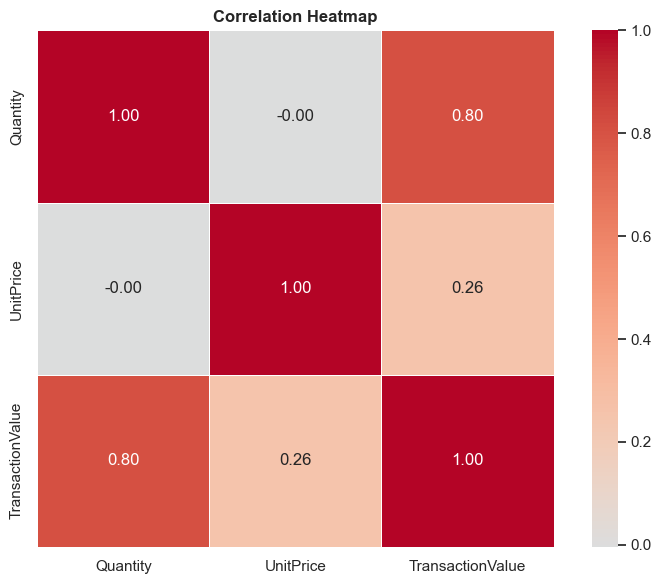

,Quantity,UnitPrice,TransactionValue
Quantity,1.00,-0.00,0.80
UnitPrice,-0.00,1.00,0.26
TransactionValue,0.80,0.26,1.00


In [11]:
corr_cols = ['Quantity', 'UnitPrice', 'TransactionValue']
corr_matrix = sales_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

corr_matrix

**Business insight:** Correlation analysis helps distinguish volume-driven revenue from price-driven revenue. If quantity and sales value move together strongly, product demand is the main lever; if unit price drives revenue more heavily, pricing and mix optimization become more important.

## Executive Summary

- The dataset is a multi-sheet retail transaction log that can be consolidated cleanly into one analytical table.
- Cancellation behavior and duplicate control should be part of the production data-quality layer.
- Monthly sales, country concentration, and top-product concentration are the strongest planning views for RetailPulse.
- Customer purchasing is skewed, so retention and segmentation should be first-class analytics features.
- The next best enhancement would be margin analysis if cost data becomes available.